In [1]:
import os
import time
import copy
import json
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader

from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import label_binarize

In [2]:
DATA_DIR = "/kaggle/input/datasets/lfreedom2750/mcvsld-split-version"

BATCH_SIZE = 64
IMAGE_SIZE = 224
NUM_WORKERS = 2

# Đây là số epoch tối đa.
# Early stopping sẽ tự dừng nếu model không còn tốt lên.
MAX_EPOCHS = 50

SAVE_DIR = Path("experiments/vgg16_optimizer_search")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [3]:
common_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [4]:
train_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "train"),
    transform=common_transform
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "val"),
    transform=common_transform
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "test"),
    transform=common_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

CLASS_NAMES = train_dataset.classes
CLASS_TO_IDX = train_dataset.class_to_idx
NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print("Class to index:", CLASS_TO_IDX)
print("Num classes:", NUM_CLASSES)
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Classes: ['Chickenpox', 'Cowpox', 'HFMD', 'Healthy', 'Measles', 'Monkeypox']
Class to index: {'Chickenpox': 0, 'Cowpox': 1, 'HFMD': 2, 'Healthy': 3, 'Measles': 4, 'Monkeypox': 5}
Num classes: 6
Train samples: 602
Val samples: 74
Test samples: 79


In [5]:
def count_per_class(dataset):
    counts = {}

    for _, label in dataset.samples:
        class_name = dataset.classes[label]
        counts[class_name] = counts.get(class_name, 0) + 1

    return counts


train_counts = count_per_class(train_dataset)
val_counts = count_per_class(val_dataset)
test_counts = count_per_class(test_dataset)

stats_df = pd.DataFrame({
    "train": pd.Series(train_counts),
    "val": pd.Series(val_counts),
    "test": pd.Series(test_counts)
}).fillna(0).astype(int)

stats_df["total"] = stats_df.sum(axis=1)

display(stats_df)

,train,val,test,total
Chickenpox,60,7,8,75
Cowpox,52,7,7,66
HFMD,128,16,17,161
Healthy,91,11,12,114
Measles,44,5,6,55
Monkeypox,227,28,29,284


In [6]:
from torchvision.models import VGG16_Weights

def create_model(num_classes):
    weights = VGG16_Weights.IMAGENET1K_V1
    model = models.vgg16(weights=weights)

    in_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(in_features, num_classes)

    return model

In [7]:
def format_epoch_time(seconds):
    minutes = int(seconds // 60)
    secs = seconds % 60

    if minutes > 0:
        return f"{minutes}m {secs:.0f}s"

    return f"{secs:.0f}s"


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def compute_specificity_multiclass(conf_matrix):
    specificities = []

    for i in range(conf_matrix.shape[0]):
        tp = conf_matrix[i, i]
        fn = conf_matrix[i, :].sum() - tp
        fp = conf_matrix[:, i].sum() - tp
        tn = conf_matrix.sum() - (tp + fn + fp)

        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        specificities.append(specificity)

    return float(np.mean(specificities)), specificities


def evaluate_model(model, loader, criterion, device, num_classes):
    model.eval()

    running_loss = 0.0
    total_samples = 0

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            running_loss += loss.item() * images.size(0)
            total_samples += labels.size(0)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    avg_loss = running_loss / total_samples

    cm = confusion_matrix(y_true, y_pred)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)

    specificity_macro, specificity_per_class = compute_specificity_multiclass(cm)

    try:
        y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
        roc_auc = roc_auc_score(
            y_true_bin,
            y_prob,
            multi_class="ovr",
            average="macro"
        )
    except ValueError:
        roc_auc = None

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "roc_auc_macro_ovr": roc_auc,
        "sensitivity_macro": recall,
        "specificity_macro": specificity_macro,
        "specificity_per_class": specificity_per_class,
        "mcc": mcc,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

In [8]:
def create_optimizer(model, optimizer_name, lr):

    if optimizer_name == "Adam":

        optimizer = optim.Adam(
            model.parameters(),
            lr=lr
        )

    elif optimizer_name == "AdamW":

        optimizer = optim.AdamW(
            model.parameters(),
            lr=lr
        )

    elif optimizer_name == "SGD":

        optimizer = optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=0.9
        )

    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    return optimizer

In [9]:
COMMON_LR = 1e-4

experiment_configs = [
    {
        "optimizer": "Adam",
        "lr": COMMON_LR
    },
    {
        "optimizer": "AdamW",
        "lr": COMMON_LR
    },
    {
        "optimizer": "SGD",
        "lr": COMMON_LR
    }
]

experiment_configs

[{'optimizer': 'Adam', 'lr': 0.0001},
 {'optimizer': 'AdamW', 'lr': 0.0001},
 {'optimizer': 'SGD', 'lr': 0.0001}]

In [10]:
criterion = nn.CrossEntropyLoss()

EARLY_STOPPING_PATIENCE = 7
LR_PATIENCE = 3
LR_FACTOR = 0.5

all_results = []

# =========================
# SAVE ALL HISTORY
# =========================
all_history = []

best_overall_score = -1
best_overall_info = None
best_overall_weights = None

for exp_id, config in enumerate(experiment_configs, start=1):

    print("\n" + "=" * 90)
    print(f"Experiment {exp_id}/{len(experiment_configs)}")
    print(
        f"Optimizer: {config['optimizer']} | "
        f"Initial LR: {config['lr']}"
    )
    print("=" * 90)

    # =========================
    # CREATE MODEL
    # =========================
    model = create_model(NUM_CLASSES).to(DEVICE)

    optimizer = create_optimizer(
        model=model,
        optimizer_name=config["optimizer"],
        lr=config["lr"]
    )

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=LR_FACTOR,
        patience=LR_PATIENCE
    )

    best_val_acc = 0.0
    best_val_f1 = 0.0
    best_epoch = 0
    best_lr = config["lr"]

    best_weights = None

    early_counter = 0

    # =========================
    # HISTORY OF CURRENT OPTIMIZER
    # =========================
    history_rows = []

    # =========================
    # TRAIN LOOP
    # =========================
    for epoch in range(1, MAX_EPOCHS + 1):

        start_time = time.time()

        train_loss, train_acc = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=DEVICE
        )

        val_metrics = evaluate_model(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=DEVICE,
            num_classes=NUM_CLASSES
        )

        val_loss = val_metrics["loss"]
        val_acc = val_metrics["accuracy"]
        val_f1 = val_metrics["f1_macro"]

        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        epoch_time = time.time() - start_time

        # =========================
        # SAVE HISTORY ROW
        # =========================
        history_rows.append({
            "experiment_id": exp_id,
            "optimizer": config["optimizer"],
            "epoch": epoch,
            "current_lr": current_lr,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1
        })

        print(
            f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"{format_epoch_time(epoch_time)} | "
            f"lr: {current_lr:.8f} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"val_acc: {val_acc:.4f} | "
            f"val_f1: {val_f1:.4f}"
        )

        # =========================
        # SAVE BEST
        # =========================
        if val_acc > best_val_acc:
        
            best_val_acc = val_acc
            best_val_f1 = val_f1
            best_epoch = epoch
            best_lr = current_lr
        
            best_weights = copy.deepcopy(model.state_dict())
        
            early_counter = 0
        
        else:
        
            early_counter += 1
        
            print(
                f"Early stopping counter: "
                f"{early_counter}/{EARLY_STOPPING_PATIENCE}"
            )
        
            if early_counter >= EARLY_STOPPING_PATIENCE:
        
                print("Early stopping triggered.")
                break

    # =========================
    # SAVE HISTORY OF THIS OPTIMIZER
    # =========================
    history_df = pd.DataFrame(history_rows)

    all_history.append(history_df)

    # =========================
    # LOAD BEST MODEL
    # =========================
    model.load_state_dict(best_weights)

    # =========================
    # TEST
    # =========================
    test_metrics = evaluate_model(
        model=model,
        loader=test_loader,
        criterion=criterion,
        device=DEVICE,
        num_classes=NUM_CLASSES
    )

    # =========================
    # SAVE MODEL
    # =========================
    model_path = SAVE_DIR / f"best_{config['optimizer']}.pth"

    torch.save({
        "model_state_dict": best_weights,
        "optimizer": config["optimizer"],
        "best_lr": best_lr,
        "best_epoch": best_epoch,
        "class_names": CLASS_NAMES,
        "class_to_idx": CLASS_TO_IDX,
        "num_classes": NUM_CLASSES,
        "image_size": IMAGE_SIZE,
        "normalize_mean": [0.485, 0.456, 0.406],
        "normalize_std": [0.229, 0.224, 0.225]
    }, model_path)

    # =========================
    # SAVE RESULTS
    # =========================
    result = {
        "optimizer": config["optimizer"],
        "initial_lr": config["lr"],
        "best_lr": best_lr,
        "best_epoch": best_epoch,
        "best_val_acc": best_val_acc,
        "best_val_f1": best_val_f1,
        "test_acc": test_metrics["accuracy"],
        "test_f1": test_metrics["f1_macro"],
        "test_precision": test_metrics["precision_macro"],
        "test_recall": test_metrics["recall_macro"],
        "test_mcc": test_metrics["mcc"],
        "model_path": str(model_path)
    }

    all_results.append(result)

    print("\nFINAL RESULT")
    print(result)

    # =========================
    # BEST OVERALL
    # =========================
    if best_val_f1 > best_overall_score:

        best_overall_score = best_val_f1

        best_overall_info = result

        best_overall_weights = copy.deepcopy(best_weights)

# =========================
# COMBINE ALL HISTORY
# =========================
full_history_df = pd.concat(all_history, ignore_index=True)

history_path = SAVE_DIR / "training_history.csv"

full_history_df.to_csv(history_path, index=False)

print("\nSaved history:", history_path)

display(full_history_df.head())


Experiment 1/3
Optimizer: Adam | Initial LR: 0.0001
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 236MB/s]


Epoch 01/50 | 11s | lr: 0.00010000 | train_loss: 1.3377 | train_acc: 0.4900 | val_loss: 1.0260 | val_acc: 0.6216 | val_f1: 0.4876
Epoch 02/50 | 10s | lr: 0.00010000 | train_loss: 0.7305 | train_acc: 0.7425 | val_loss: 1.0166 | val_acc: 0.7027 | val_f1: 0.6227
Epoch 03/50 | 10s | lr: 0.00010000 | train_loss: 0.3707 | train_acc: 0.8688 | val_loss: 0.6201 | val_acc: 0.8108 | val_f1: 0.7452
Epoch 04/50 | 10s | lr: 0.00010000 | train_loss: 0.1289 | train_acc: 0.9601 | val_loss: 0.5709 | val_acc: 0.8243 | val_f1: 0.7349
Epoch 05/50 | 10s | lr: 0.00010000 | train_loss: 0.0925 | train_acc: 0.9701 | val_loss: 0.7250 | val_acc: 0.8243 | val_f1: 0.7883
Early stopping counter: 1/7
Epoch 06/50 | 11s | lr: 0.00010000 | train_loss: 0.0645 | train_acc: 0.9784 | val_loss: 0.7357 | val_acc: 0.8243 | val_f1: 0.7487
Early stopping counter: 2/7
Epoch 07/50 | 11s | lr: 0.00010000 | train_loss: 0.0559 | train_acc: 0.9751 | val_loss: 0.8591 | val_acc: 0.7568 | val_f1: 0.7114
Early stopping counter: 3/7
Epoch 

,experiment_id,optimizer,epoch,current_lr,train_loss,train_acc,val_loss,val_acc,val_f1
0,1,Adam,1,0.0001,1.337658,0.490033,1.026039,0.621622,0.487646
1,1,Adam,2,0.0001,0.730509,0.742525,1.016552,0.702703,0.622652
2,1,Adam,3,0.0001,0.370655,0.868771,0.620096,0.810811,0.745164
3,1,Adam,4,0.0001,0.128915,0.960133,0.570927,0.824324,0.734880
4,1,Adam,5,0.0001,0.092489,0.970100,0.724978,0.824324,0.788267


In [11]:
# =========================
# RESULTS DATAFRAME
# =========================
results_df = pd.DataFrame(all_results)

# SORT BY BEST VALIDATION F1
results_df = results_df.sort_values(
    by=["best_val_f1", "test_f1"],
    ascending=False
).reset_index(drop=True)

# ADD RANK
results_df.insert(0, "rank", range(1, len(results_df) + 1))

display(results_df)

# =========================
# SAVE RESULTS
# =========================
results_path = SAVE_DIR / "optimizer_comparison.csv"

results_df.to_csv(results_path, index=False)

print("Saved:", results_path)

,rank,optimizer,initial_lr,best_lr,best_epoch,best_val_acc,best_val_f1,test_acc,test_f1,test_precision,test_recall,test_mcc,model_path
0,1,AdamW,0.0001,0.00005,9,0.837838,0.786688,0.759494,0.718666,0.750490,0.728183,0.700643,experiments/vgg16_optimizer_search/best_AdamW.pth
1,2,SGD,0.0001,0.00010,31,0.810811,0.750454,0.746835,0.681123,0.764312,0.670055,0.670082,experiments/vgg16_optimizer_search/best_SGD.pth
2,3,Adam,0.0001,0.00010,4,0.824324,0.734880,0.822785,0.804074,0.812189,0.810900,0.773434,experiments/vgg16_optimizer_search/best_Adam.pth


Saved: experiments/vgg16_optimizer_search/optimizer_comparison.csv


In [12]:
print("=" * 80)
print("BEST OPTIMIZER")
print("=" * 80)

print("Optimizer      :", best_overall_info["optimizer"])
print("Initial LR     :", best_overall_info["initial_lr"])
print("Best LR        :", best_overall_info["best_lr"])
print("Best Epoch     :", best_overall_info["best_epoch"])

print("\nValidation:")
print("Best val acc   :", round(best_overall_info["best_val_acc"], 4))
print("Best val F1    :", round(best_overall_info["best_val_f1"], 4))

print("\nTest:")
print("Test acc       :", round(best_overall_info["test_acc"], 4))
print("Test F1        :", round(best_overall_info["test_f1"], 4))
print("Test precision :", round(best_overall_info["test_precision"], 4))
print("Test recall    :", round(best_overall_info["test_recall"], 4))
print("Test MCC       :", round(best_overall_info["test_mcc"], 4))

print("\nBest model path:")
print(best_overall_info["model_path"])

BEST OPTIMIZER
Optimizer      : AdamW
Initial LR     : 0.0001
Best LR        : 5e-05
Best Epoch     : 9

Validation:
Best val acc   : 0.8378
Best val F1    : 0.7867

Test:
Test acc       : 0.7595
Test F1        : 0.7187
Test precision : 0.7505
Test recall    : 0.7282
Test MCC       : 0.7006

Best model path:
experiments/vgg16_optimizer_search/best_AdamW.pth


In [13]:
best_model_path = f"{best_overall_info['model_path']}"

checkpoint = torch.load(
    best_model_path,
    map_location=DEVICE
)

model = create_model(checkpoint["num_classes"])

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)
model.eval()

print("Loaded model from:")
print(best_model_path)

print("\nCheckpoint keys:")
print(checkpoint.keys())

Loaded model from:
experiments/vgg16_optimizer_search/best_AdamW.pth

Checkpoint keys:
dict_keys(['model_state_dict', 'optimizer', 'best_lr', 'best_epoch', 'class_names', 'class_to_idx', 'num_classes', 'image_size', 'normalize_mean', 'normalize_std'])


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

def print_all_metrics(metrics, class_names, split_name="Evaluation"):
    print(f"\n===== {split_name.upper()} METRICS =====")

    print(f"Accuracy     : {metrics['accuracy']:.4f}")
    print(f"Precision    : {metrics['precision_macro']:.4f}")
    print(f"Recall       : {metrics['recall_macro']:.4f}")
    print(f"F1-score     : {metrics['f1_macro']:.4f}")

    if metrics["roc_auc_macro_ovr"] is not None:
        print(f"ROC-AUC      : {metrics['roc_auc_macro_ovr']:.4f}")
    else:
        print("ROC-AUC      : None")

    print(f"Sensitivity  : {metrics['sensitivity_macro']:.4f}")
    print(f"Specificity  : {metrics['specificity_macro']:.4f}")
    print(f"MCC          : {metrics['mcc']:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            metrics["y_true"],
            metrics["y_pred"],
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )


def plot_confusion_matrix(metrics, class_names, split_name="Evaluation", save_path=None):
    cm = metrics["confusion_matrix"]

    fig, ax = plt.subplots(figsize=(8, 6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=45,
        colorbar=True
    )

    ax.set_title(f"{split_name} Confusion Matrix")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved confusion matrix:", save_path)

    plt.show()


===== TRAIN METRICS =====
Accuracy     : 1.0000
Precision    : 1.0000
Recall       : 1.0000
F1-score     : 1.0000
ROC-AUC      : 1.0000
Sensitivity  : 1.0000
Specificity  : 1.0000
MCC          : 1.0000

Classification Report:
              precision    recall  f1-score   support

  Chickenpox     1.0000    1.0000    1.0000        60
      Cowpox     1.0000    1.0000    1.0000        52
        HFMD     1.0000    1.0000    1.0000       128
     Healthy     1.0000    1.0000    1.0000        91
     Measles     1.0000    1.0000    1.0000        44
   Monkeypox     1.0000    1.0000    1.0000       227

    accuracy                         1.0000       602
   macro avg     1.0000    1.0000    1.0000       602
weighted avg     1.0000    1.0000    1.0000       602

Saved confusion matrix: experiments/vgg16_optimizer_search/train_confusion_matrix.png


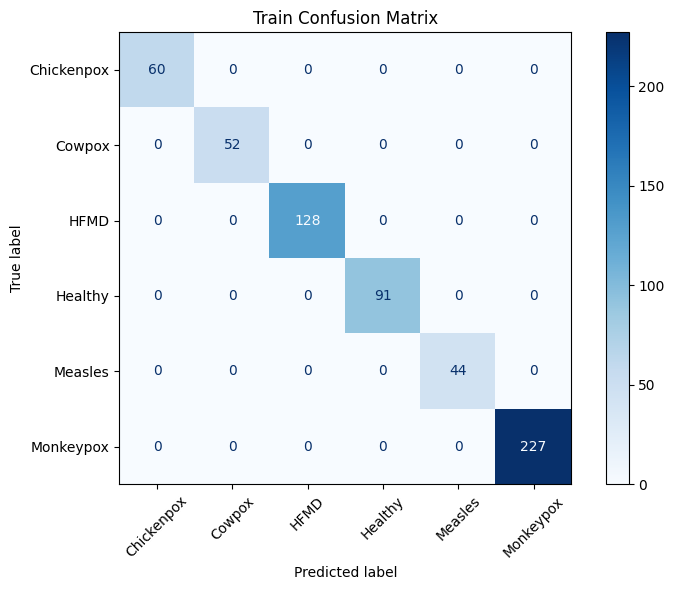

In [15]:
train_metrics = evaluate_model(
    model=model,
    loader=train_loader,
    criterion=criterion,
    device=DEVICE,
    num_classes=NUM_CLASSES
)

print_all_metrics(
    metrics=train_metrics,
    class_names=CLASS_NAMES,
    split_name="Train"
)

plot_confusion_matrix(
    metrics=train_metrics,
    class_names=CLASS_NAMES,
    split_name="Train",
    save_path=SAVE_DIR / "train_confusion_matrix.png"
)


===== VALIDATION METRICS =====
Accuracy     : 0.8378
Precision    : 0.8144
Recall       : 0.7756
F1-score     : 0.7867
ROC-AUC      : 0.9669
Sensitivity  : 0.7756
Specificity  : 0.9636
MCC          : 0.7871

Classification Report:
              precision    recall  f1-score   support

  Chickenpox     0.7143    0.7143    0.7143         7
      Cowpox     0.7500    0.4286    0.5455         7
        HFMD     0.8889    1.0000    0.9412        16
     Healthy     0.9000    0.8182    0.8571        11
     Measles     0.8000    0.8000    0.8000         5
   Monkeypox     0.8333    0.8929    0.8621        28

    accuracy                         0.8378        74
   macro avg     0.8144    0.7756    0.7867        74
weighted avg     0.8339    0.8378    0.8303        74

Saved confusion matrix: experiments/vgg16_optimizer_search/validation_confusion_matrix.png


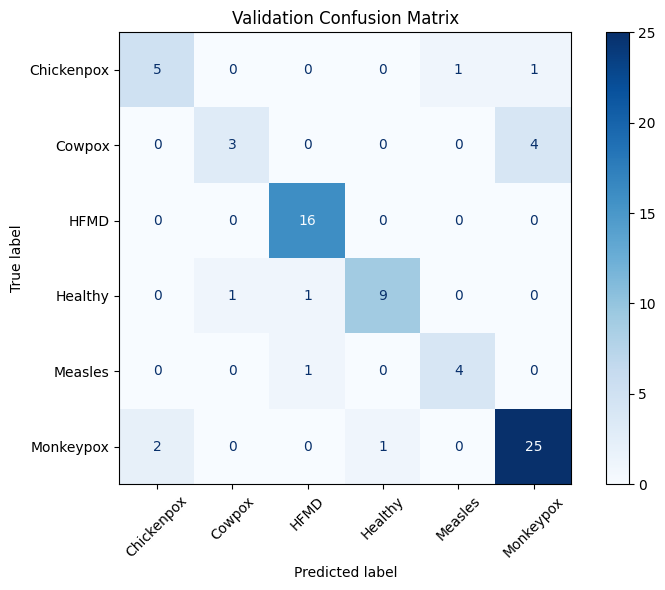

In [16]:
val_metrics = evaluate_model(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=DEVICE,
    num_classes=NUM_CLASSES
)

print_all_metrics(
    metrics=val_metrics,
    class_names=CLASS_NAMES,
    split_name="Validation"
)

plot_confusion_matrix(
    metrics=val_metrics,
    class_names=CLASS_NAMES,
    split_name="Validation",
    save_path=SAVE_DIR / "validation_confusion_matrix.png"
)


===== TEST METRICS =====
Accuracy     : 0.7595
Precision    : 0.7505
Recall       : 0.7282
F1-score     : 0.7187
ROC-AUC      : 0.9657
Sensitivity  : 0.7282
Specificity  : 0.9514
MCC          : 0.7006

Classification Report:
              precision    recall  f1-score   support

  Chickenpox     0.5455    0.7500    0.6316         8
      Cowpox     1.0000    0.5714    0.7273         7
        HFMD     0.7778    0.8235    0.8000        17
     Healthy     0.6667    1.0000    0.8000        12
     Measles     0.6000    0.5000    0.5455         6
   Monkeypox     0.9130    0.7241    0.8077        29

    accuracy                         0.7595        79
   macro avg     0.7505    0.7282    0.7187        79
weighted avg     0.7932    0.7595    0.7600        79

Saved confusion matrix: experiments/vgg16_optimizer_search/test_confusion_matrix.png


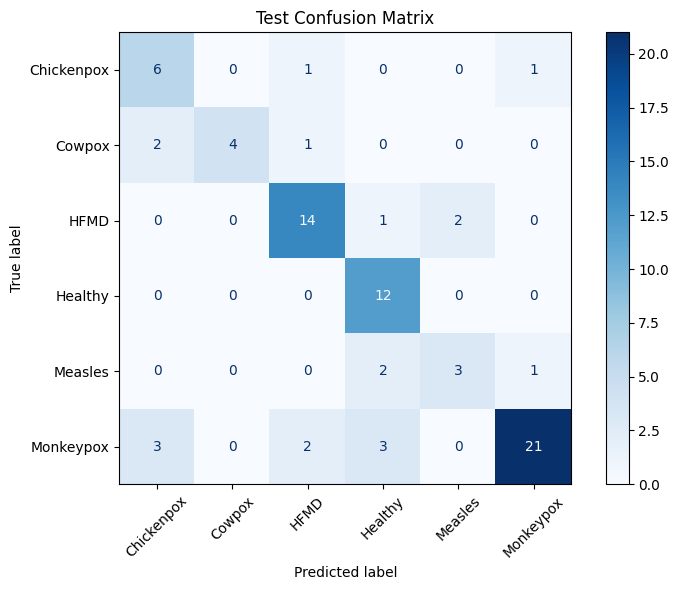

In [17]:
test_metrics = evaluate_model(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=DEVICE,
    num_classes=NUM_CLASSES
)

print_all_metrics(
    metrics=test_metrics,
    class_names=CLASS_NAMES,
    split_name="Test"
)

plot_confusion_matrix(
    metrics=test_metrics,
    class_names=CLASS_NAMES,
    split_name="Test",
    save_path=SAVE_DIR / "test_confusion_matrix.png"
)

In [18]:
import matplotlib.pyplot as plt
import torch
import random

# =========================
# COLLECT CORRECT / WRONG SAMPLES
# =========================

def unnormalize_img(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    img = img_tensor.cpu() * std + mean
    img = torch.clamp(img, 0, 1)

    return img.permute(1, 2, 0).numpy()


def collect_prediction_samples(model, loader, dataset, device):
    model.eval()

    correct_samples = []
    wrong_samples = []

    sample_idx = 0

    with torch.no_grad():
        for images, labels in loader:
            images_device = images.to(device)
            labels_device = labels.to(device)

            outputs = model(images_device)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            for i in range(images.size(0)):
                img_path = dataset.samples[sample_idx][0]

                item = {
                    "image": images[i],
                    "path": img_path,
                    "true_label": labels[i].item(),
                    "pred_label": preds[i].cpu().item(),
                    "confidence": probs[i][preds[i]].cpu().item()
                }

                if item["true_label"] == item["pred_label"]:
                    correct_samples.append(item)
                else:
                    wrong_samples.append(item)

                sample_idx += 1

    return correct_samples, wrong_samples


correct_samples, wrong_samples = collect_prediction_samples(
    model=model,
    loader=test_loader,
    dataset=test_dataset,
    device=DEVICE
)

print("Correct samples:", len(correct_samples))
print("Wrong samples:", len(wrong_samples))

Correct samples: 60
Wrong samples: 19


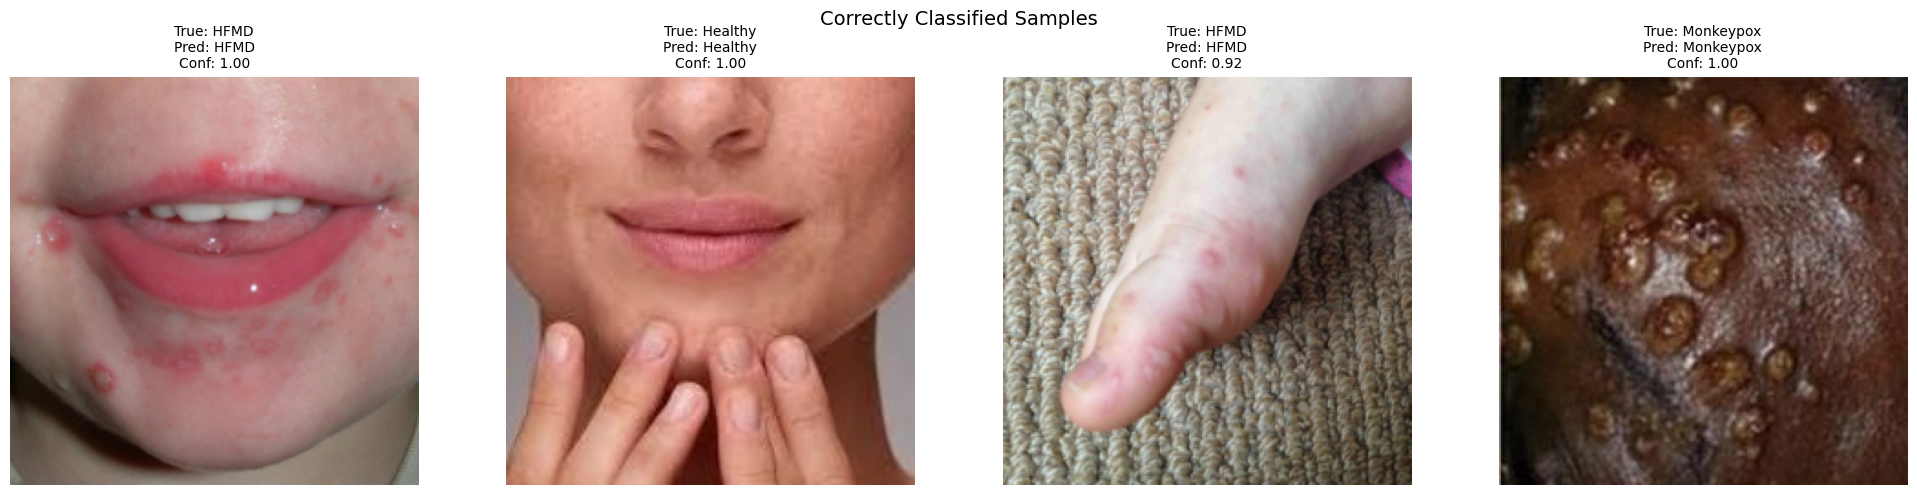

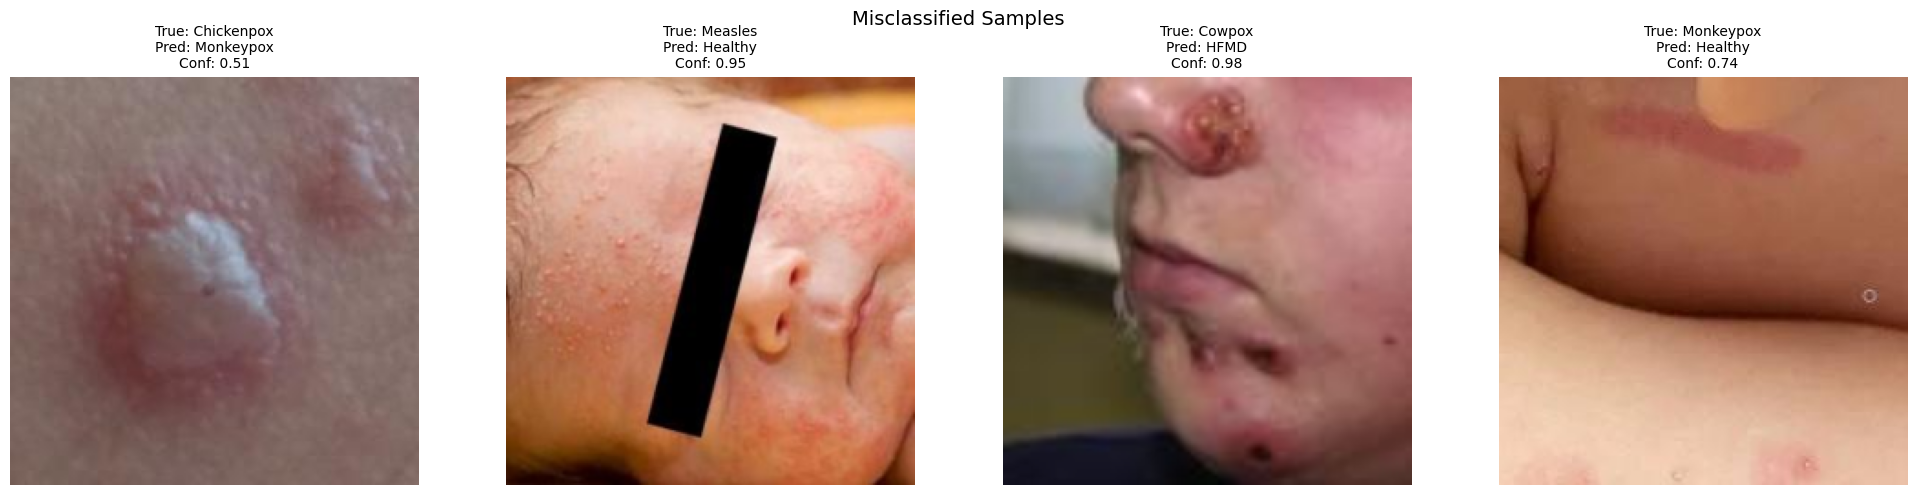

In [19]:
# =========================
# SHOW 3 CORRECT + 3 WRONG
# =========================

def show_samples(samples, class_names, title, n=3):
    n = min(n, len(samples))

    selected = random.sample(samples, n)

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))

    if n == 1:
        axes = [axes]

    for ax, item in zip(axes, selected):
        img = unnormalize_img(item["image"])

        true_name = class_names[item["true_label"]]
        pred_name = class_names[item["pred_label"]]
        conf = item["confidence"]

        ax.imshow(img)
        ax.set_title(
            f"True: {true_name}\nPred: {pred_name}\nConf: {conf:.2f}",
            fontsize=10
        )
        ax.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


show_samples(
    samples=correct_samples,
    class_names=CLASS_NAMES,
    title="Correctly Classified Samples",
    n=4
)

show_samples(
    samples=wrong_samples,
    class_names=CLASS_NAMES,
    title="Misclassified Samples",
    n=4
)

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

full_history_df = pd.concat(all_history, ignore_index=True)

history_path = SAVE_DIR / "training_history.csv"

full_history_df.to_csv(history_path, index=False)

print("Saved:", history_path)

display(full_history_df.head())

Saved: experiments/vgg16_optimizer_search/training_history.csv


,experiment_id,optimizer,epoch,current_lr,train_loss,train_acc,val_loss,val_acc,val_f1
0,1,Adam,1,0.0001,1.337658,0.490033,1.026039,0.621622,0.487646
1,1,Adam,2,0.0001,0.730509,0.742525,1.016552,0.702703,0.622652
2,1,Adam,3,0.0001,0.370655,0.868771,0.620096,0.810811,0.745164
3,1,Adam,4,0.0001,0.128915,0.960133,0.570927,0.824324,0.734880
4,1,Adam,5,0.0001,0.092489,0.970100,0.724978,0.824324,0.788267


Best optimizer: AdamW


,experiment_id,optimizer,epoch,current_lr,train_loss,train_acc,val_loss,val_acc,val_f1
11,2,AdamW,1,0.0001,1.437850,0.445183,1.153446,0.608108,0.482458
12,2,AdamW,2,0.0001,0.798801,0.714286,0.933710,0.608108,0.514263
13,2,AdamW,3,0.0001,0.505915,0.807309,0.818293,0.662162,0.561957
14,2,AdamW,4,0.0001,0.227310,0.920266,0.663329,0.810811,0.752657
15,2,AdamW,5,0.0001,0.096080,0.956811,0.896217,0.783784,0.729195


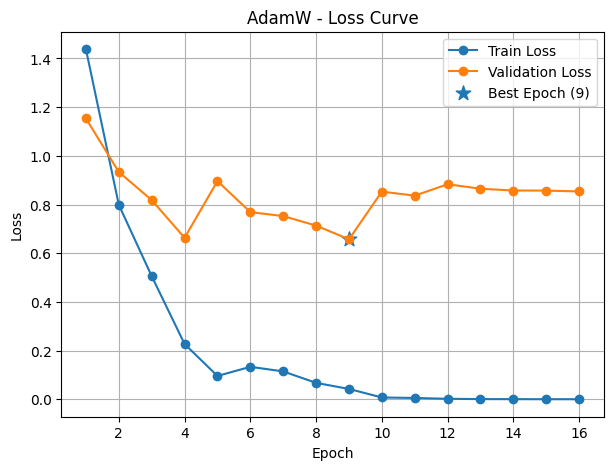

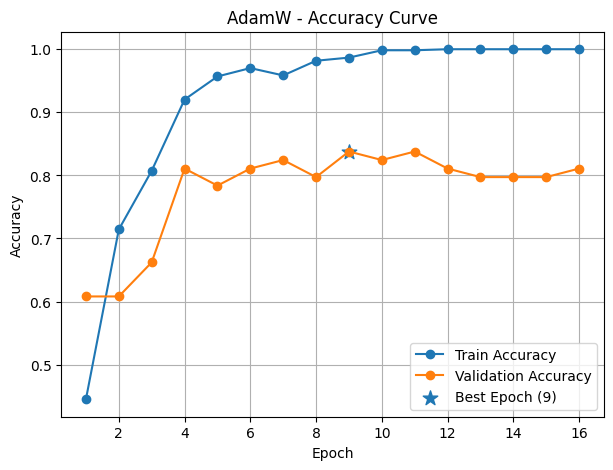

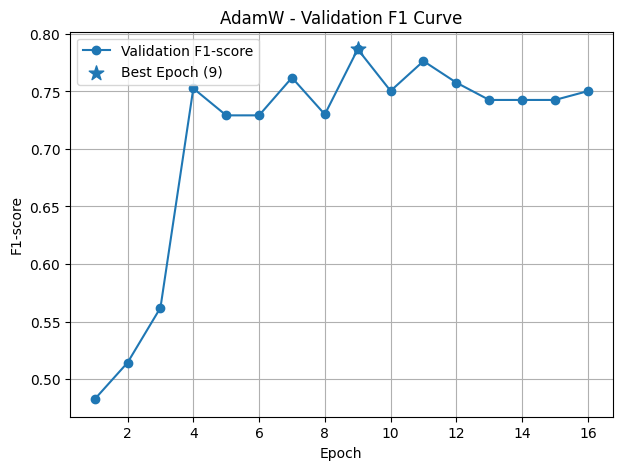

In [21]:
import matplotlib.pyplot as plt

# =========================
# GET BEST OPTIMIZER HISTORY
# =========================

best_optimizer_name = best_overall_info["optimizer"]

best_history_df = full_history_df[
    full_history_df["optimizer"] == best_optimizer_name
].copy()

print("Best optimizer:", best_optimizer_name)

display(best_history_df.head())

# =========================
# PLOT LOSS
# =========================

plt.figure(figsize=(7, 5))

plt.plot(
    best_history_df["epoch"],
    best_history_df["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    best_history_df["epoch"],
    best_history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

# highlight best epoch
best_epoch = best_overall_info["best_epoch"]

best_row = best_history_df[
    best_history_df["epoch"] == best_epoch
].iloc[0]

plt.scatter(
    best_epoch,
    best_row["val_loss"],
    s=120,
    marker="*",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{best_optimizer_name} - Loss Curve")
plt.legend()
plt.grid(True)

plt.show()

# =========================
# PLOT ACCURACY
# =========================

plt.figure(figsize=(7, 5))

plt.plot(
    best_history_df["epoch"],
    best_history_df["train_acc"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    best_history_df["epoch"],
    best_history_df["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.scatter(
    best_epoch,
    best_row["val_acc"],
    s=120,
    marker="*",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"{best_optimizer_name} - Accuracy Curve")
plt.legend()
plt.grid(True)

plt.show()

# =========================
# PLOT VALIDATION F1
# =========================

plt.figure(figsize=(7, 5))

plt.plot(
    best_history_df["epoch"],
    best_history_df["val_f1"],
    marker="o",
    label="Validation F1-score"
)

plt.scatter(
    best_epoch,
    best_row["val_f1"],
    s=120,
    marker="*",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title(f"{best_optimizer_name} - Validation F1 Curve")
plt.legend()
plt.grid(True)

plt.show()